In [88]:
import numpy as np
import pandas as pd
from sklearn.utils import Bunch
from sklearn.datasets import fetch_california_housing
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeRegressor
from sklearn import tree
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn import metrics



## Question 3

In [89]:
# A function that takes a sorted array, y and splits it into y_left and y_right and find the optimum split to minimize MSE

def find_best_split(y):
    #index represent last element in the below threshold node
    sq_err_vec      = np.zeros(len(y) - 1)
    mean_sq_err_vec = np.zeros(len(y) - 1)

    for idx in range(0 , len(y)-1):

        #split the sorted data into above and below threshold
        data_below_threshold = y[:idx + 1]
        data_above_threshold = y[idx + 1:]

        #compute the estimate for both node
        mean_below_threshold = np.mean(data_below_threshold)
        mean_above_threshold = np.mean(data_above_threshold)

        #compute the total square error and store it for each index
        below_sq_err = np.sum(np.square(data_below_threshold - mean_below_threshold))
        above_sq_err = np.sum(np.square(data_above_threshold - mean_above_threshold))

        sq_err_vec[idx] = below_sq_err + above_sq_err
        mean_sq_err_vec[idx] = sq_err_vec[idx]/len(y)

    best_index = np.argmin(mean_sq_err_vec) #optimum split is the minimum of sq error
    y_left = y[:best_index + 1]
    y_right = y[best_index + 1:]
    return y_left, y_right


In [90]:
def our_own_tree(y):
    #split data at first level
    y_left, y_right = find_best_split(y)

    y_left_pred = np.mean(y_left)*np.ones(len(y_left))
    y_right_pred = np.mean(y_right)*np.ones(len(y_right))

    y_pred = np.concatenate((y_left_pred, y_right_pred))

    return y_pred


In [91]:
def calculate_mse(y):
    """Helper to calculate MSE of a set of target values."""
    if len(y) == 0: return 0
    return np.mean((y - np.mean(y))**2)

In [92]:
def grow_tree(y, current_depth, max_depth,node_name="Root"):
    # Base case: if we reached max depth, return the mean
    current_mse = calculate_mse(y)
    indent = "  " * current_depth
    print(f"{indent}Node: {node_name} | Depth: {current_depth} | MSE: {current_mse:.4f} | N: {len(y)}")
    if current_depth == max_depth:
        return np.mean(y) * np.ones(len(y))

    # Recursive case: split and go deeper
    y_left, y_right = find_best_split(y)

    left_predictions = grow_tree(y_left, current_depth + 1, max_depth, node_name="Left")
    right_predictions = grow_tree(y_right, current_depth + 1, max_depth, node_name ='Right')

    return np.concatenate((left_predictions, right_predictions))

In [93]:
df = pd.read_csv('housing.csv')
target_col = 'median_house_value'
feature_cols = [col for col in df.columns if col != target_col]
housing = Bunch(
    data=df[feature_cols],
    target=df[target_col],
    frame = df,
    target_names = [target_col],
    feature_names = feature_cols,
    DESCR = "California Housing Data"
)
print(housing.target_names)
print(housing.feature_names)
print(housing.data.head())

X = housing.data.values[:,7] #use median income as input feature
y = housing.target.values
sort_index = X.argsort()
X = X[sort_index]
y = y[sort_index]

print(X)

['median_house_value']
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity']
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income ocean_proximity  
0       322.0       126.0         8.3252        NEAR BAY  
1      2401.0      1138.0         8.3014        NEAR BAY  
2       496.0       177.0         7.2574        NEAR BAY  
3       558.0       219.0         5.6431        NEAR BAY  
4       565.0       259.0         3.8462        NEAR BAY  
[0.4999 0.4999 0.4999 ... 1

In [96]:
#scikit decision tree regressor
scikit_tree = DecisionTreeRegressor(criterion='squared_error', max_depth = 3)
scikit_tree.fit(X.reshape(-1,1),y)
scikit_tree_predict = scikit_tree.predict(X.reshape(-1,1))
mse_values = scikit_tree.tree_.impurity
print(f"MSE for each node: {mse_values}")


#our own tree regressor
tree_predict = grow_tree(y,0,3)


MSE for each node: [1.33155030e+10 8.37353517e+09 5.61155435e+09 4.95145703e+09
 5.65195274e+09 8.36995078e+09 7.91887270e+09 8.22724894e+09
 1.22071338e+10 8.90549894e+09 8.27556747e+09 8.22548458e+09
 7.78439971e+09 7.65548143e+09 4.91907790e+09]
Node: Root | Depth: 0 | MSE: 13315503000.8181 | N: 20640
  Node: Left | Depth: 1 | MSE: 8373535166.3631 | N: 16255
    Node: Left | Depth: 2 | MSE: 5611554346.5816 | N: 7860
      Node: Left | Depth: 3 | MSE: 4951457025.7464 | N: 4197
      Node: Right | Depth: 3 | MSE: 5651952739.9177 | N: 3663
    Node: Right | Depth: 2 | MSE: 8369950776.7809 | N: 8395
      Node: Left | Depth: 3 | MSE: 7918872702.7395 | N: 5075
      Node: Right | Depth: 3 | MSE: 8227248937.1234 | N: 3320
  Node: Right | Depth: 1 | MSE: 12207133796.0380 | N: 4385
    Node: Left | Depth: 2 | MSE: 8905498937.5546 | N: 3047
      Node: Left | Depth: 3 | MSE: 8275567468.3587 | N: 1756
      Node: Right | Depth: 3 | MSE: 8225484575.5190 | N: 1291
    Node: Right | Depth: 2 | M

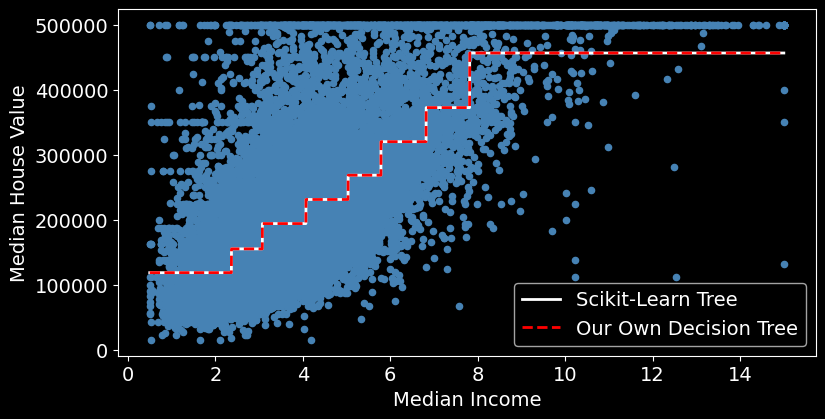

In [97]:
plt.figure(0, figsize=(9,4.5))
plt.rcParams.update({'font.size': 14})
plt.scatter(X, y, c='steelblue', s=20)
plt.plot(X, scikit_tree_predict, c='white', lw =2, label = "Scikit-Learn Tree")
plt.plot(X, tree_predict, c = 'red', linestyle = '--', lw=2 , label = "Our Own Decision Tree")
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.legend()
plt.show()

## Question 4 - Classification Tree

In [100]:
iris_dataset = load_iris()
print(iris_dataset.feature_names)
print(iris_dataset.target_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']


In [101]:
# split the dataset

X_train, X_test, y_train, y_test = train_test_split( iris_dataset['data'], iris_dataset['target'], test_size = 0.2, random_state = 42)

In [103]:
dtree = tree.DecisionTreeClassifier(criterion = 'entropy', max_depth = 4)
dtree.fit(X_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [106]:
y_train_pred = dtree.predict(X_train)
y_test_pred = dtree.predict(X_test)

print("Training accuracy", metrics.accuracy_score(y_train, y_train_pred))
print("Test accuracy", metrics.accuracy_score(y_test, y_test_pred))

Training accuracy 0.975
Test accuracy 1.0


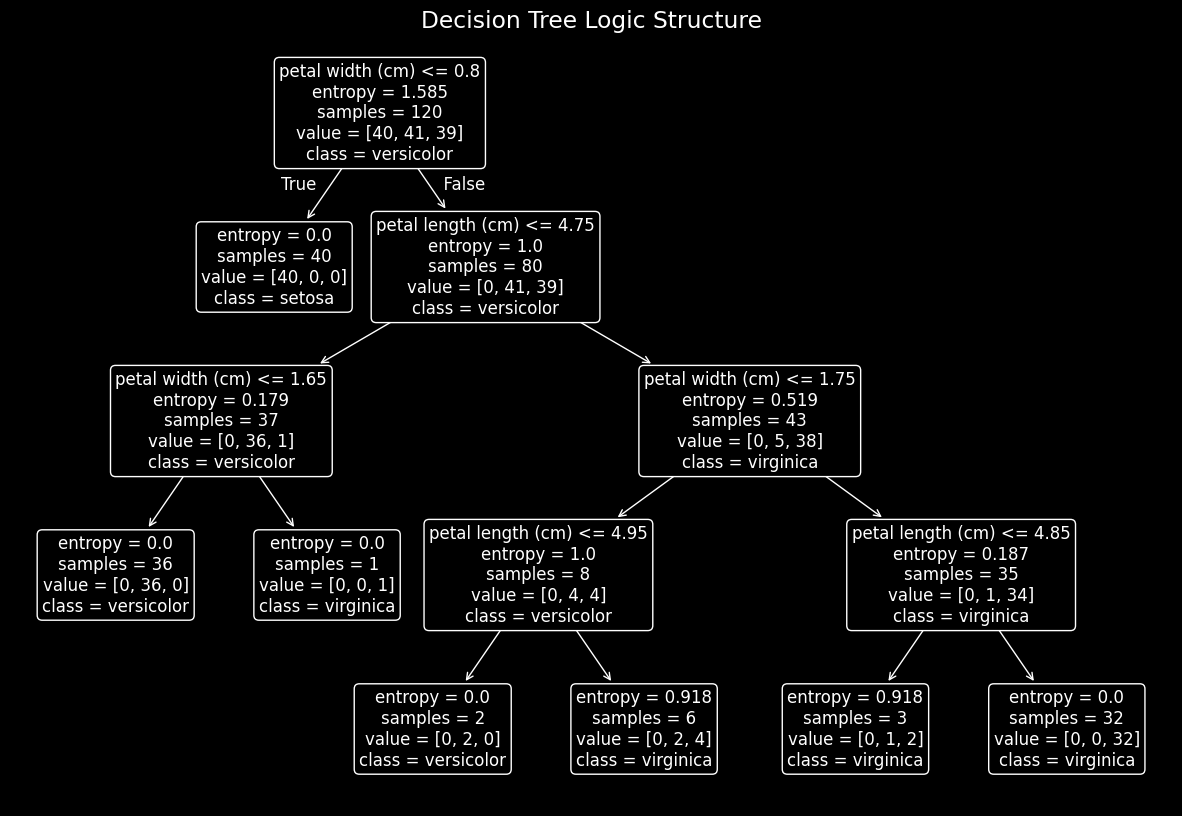

In [118]:
plt.figure(figsize=(15, 10))
plt.style.use('dark_background')

tree.plot_tree(dtree,
               feature_names=iris_dataset.feature_names,
               class_names=iris_dataset.target_names,
               filled=False,
               rounded=True,
               fontsize=12)
plt.title("Decision Tree Logic Structure")
plt.show()

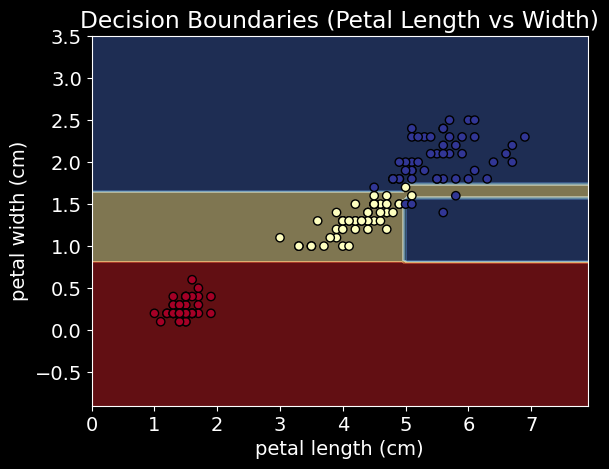

In [111]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay

# We can only plot 2 dimensions at a time, let's pick Petal Length and Width
X_plot = iris_dataset.data[:, 2:4]
y_plot = iris_dataset.target

# Re-fit a small tree for visualization purposes
clf = tree.DecisionTreeClassifier(max_depth=4).fit(X_plot, y_plot)

# Plot
disp = DecisionBoundaryDisplay.from_estimator(
    clf, X_plot, response_method="predict",
    xlabel=iris_dataset.feature_names[2], ylabel=iris_dataset.feature_names[3],
    alpha=0.5, cmap=plt.cm.RdYlBu
)
plt.scatter(X_plot[:, 0], X_plot[:, 1], c=y_plot, edgecolor="k", cmap=plt.cm.RdYlBu)
plt.title("Decision Boundaries (Petal Length vs Width)")
plt.show()

# Plug and Play Code


--- Regression Metrics ---
MSE:  0.0000
RMSE: 0.0000
R2:   1.0000


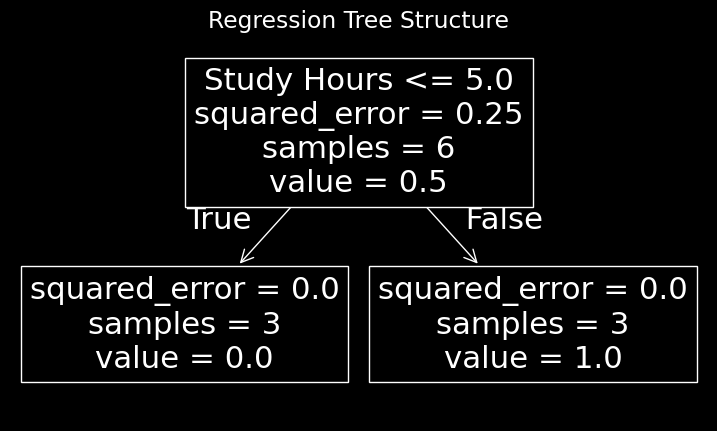

In [122]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn import metrics, tree
import matplotlib.pyplot as plt

# --- PLUG DATA HERE ---
# A tiny dataset: 6 samples, 1 feature (Study Hours), 1 Target (Pass=1, Fail=0)
X = np.array([[1], [2], [3], [7], [8], [9]])
y = np.array([0, 0, 0, 1, 1, 1])

feature_cols = ["Study Hours"]
target_names = ["Fail", "Pass"]
# ----------------------

reg_tree = DecisionTreeRegressor(max_depth=3)
reg_tree.fit(X, y)
y_pred = reg_tree.predict(X)

# --- METRICS ---
mse = metrics.mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
r2 = metrics.r2_score(y, y_pred)

print(f"--- Regression Metrics ---")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2:   {r2:.4f}")

# --- VISUALIZE (Dark Mode Friendly) ---
plt.style.use('dark_background')
plt.figure(figsize=(9, 5))
tree.plot_tree(reg_tree, filled=False, feature_names=feature_cols)
plt.title("Regression Tree Structure")
plt.show()

--- Classification Metrics ---
Accuracy:            1.0000
Misclassification:   0.0000
Root Gini:           0.5000
Root Entropy:        1.0000

Confusion Matrix:
[[3 0]
 [0 3]]


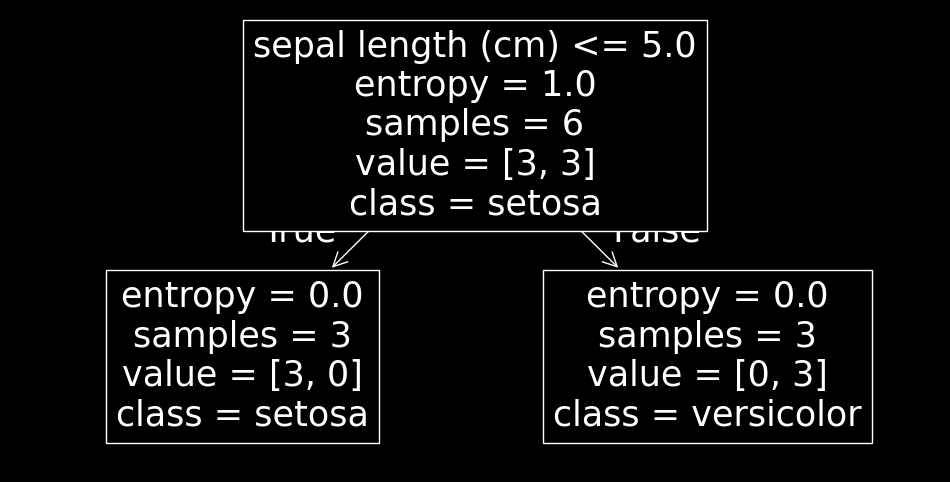

In [124]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics, tree
import matplotlib.pyplot as plt

# --- PLUG DATA HERE ---
X = np.array([[1], [2], [3], [7], [8], [9]])
y = np.array([0, 0, 0, 1, 1, 1])

feature_cols = ["Study Hours"]
target_names = ["Fail", "Pass"]
# ----------------------

clf_tree = DecisionTreeClassifier(criterion='entropy', max_depth=3)
clf_tree.fit(X, y)
y_pred = clf_tree.predict(X)

# --- METRICS ---
acc = metrics.accuracy_score(y, y_pred)
miss_rate = 1 - acc

# Manual Metric Calculation for the WHOLE set (Root Node style)
def get_metrics(y_vals):
    probs = np.bincount(y_vals) / len(y_vals)
    gini = 1 - np.sum(probs**2)
    entropy = -np.sum([p * np.log2(p) for p in probs if p > 0])
    return gini, entropy

root_gini, root_entropy = get_metrics(y)

print(f"--- Classification Metrics ---")
print(f"Accuracy:            {acc:.4f}")
print(f"Misclassification:   {miss_rate:.4f}")
print(f"Root Gini:           {root_gini:.4f}")
print(f"Root Entropy:        {root_entropy:.4f}")

# --- CONFUSION MATRIX ---
print("\nConfusion Matrix:")
print(metrics.confusion_matrix(y, y_pred))

# --- VISUALIZE ---
plt.style.use('dark_background')
plt.figure(figsize=(12, 6))
tree.plot_tree(clf_tree, filled=False,
               feature_names=iris_dataset.feature_names,
               class_names=iris_dataset.target_names)
plt.show()